## Evaluating the Amount of Training Data Required For a Char-RNN to Succesfully Produce Shakespeare Text

### Cogs 181 Final Project Notebook

Name: Ankita Inamti 

PID: A17388687


In [10]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time

### Load and encode the data

We are using tiny shakespeare dataset

In [11]:
with open("tiny-shakespeare.txt", "r") as f:
    text = f.read()

chars = sorted(set(text))
VOCAB = len(chars)
ch2i = {c: i for i, c in enumerate(chars)}
i2ch = {i: c for i, c in enumerate(chars)}

def encode(s): return [ch2i[c] for c in s]
def decode(l): return "".join(i2ch[i] for i in l)

ids = torch.tensor(encode(text), dtype=torch.long)
print(f"Total chars: {len(text):,} | Vocab size: {VOCAB}")

Total chars: 1,115,394 | Vocab size: 65


### Hyperparameters

Explain

In [12]:
HIDDEN_SIZE   = 256
SEQ_LEN       = 100
BATCH_SIZE    = 64
LEARNING_RATE = 3e-4
EPOCHS        = 5
FRACTIONS     = [0.10, 0.25, 0.50, 1.00]
SAMPLE_LEN    = 500
DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using: {DEVICE}")

Using: cuda


In [13]:
from torch.utils.data import Dataset, DataLoader

class CharDataset(Dataset):
    def __init__(self, data, seq_len):
        self.data    = data
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, i):
        x = self.data[i     : i + self.seq_len]
        y = self.data[i + 1 : i + self.seq_len + 1]
        return x, y

def make_loader(ids, fraction):
    subset = ids[:int(len(ids) * fraction)]
    ds = CharDataset(subset, SEQ_LEN)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

In [14]:
class CharRNN(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.embed  = nn.Embedding(vocab_size, hidden_size)
        self.lstm   = nn.LSTM(hidden_size, hidden_size, num_layers=2,
                              dropout=0.3, batch_first=True)
        self.fc     = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, state=None):
        x = self.embed(x)
        out, state = self.lstm(x, state)
        logits = self.fc(out)
        return logits, state

    def init_state(self, batch_size):
        h = torch.zeros(2, batch_size, self.hidden_size).to(DEVICE)
        c = torch.zeros(2, batch_size, self.hidden_size).to(DEVICE)
        return (h, c)

### Training function

In [15]:
def train(fraction):
    loader = make_loader(ids, fraction)
    model  = CharRNN(VOCAB, HIDDEN_SIZE).to(DEVICE)
    opt    = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    loss_fn = nn.CrossEntropyLoss()

    history = []
    for epoch in range(EPOCHS):
        model.train()
        total_loss, steps = 0, 0
        t0 = time.time()

        for x, y in loader:
            x, y  = x.to(DEVICE), y.to(DEVICE)
            state = model.init_state(x.size(0))
            opt.zero_grad()
            logits, _ = model(x, state)
            loss = loss_fn(logits.reshape(-1, VOCAB), y.reshape(-1))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)  # prevent exploding gradients
            opt.step()
            total_loss += loss.item()
            steps += 1

        avg_loss = total_loss / steps
        history.append(avg_loss)
        print(f"  [Epoch {epoch+1}/{EPOCHS}] loss={avg_loss:.4f} ({time.time()-t0:.1f}s)")

    return model, history

In [18]:
results = {}
for frac in FRACTIONS:
    print(f"\nTraining on {int(frac*100)}% of data...")
    model, history = train(frac)
    results[frac] = {"model": model, "history": history}


Training on 10% of data...
  [Epoch 1/5] loss=1.7684 (16.1s)
  [Epoch 2/5] loss=1.2226 (18.8s)
  [Epoch 3/5] loss=0.9473 (17.0s)
  [Epoch 4/5] loss=0.7374 (16.1s)
  [Epoch 5/5] loss=0.5919 (13.0s)

Training on 25% of data...
  [Epoch 1/5] loss=1.5599 (44.3s)
  [Epoch 2/5] loss=1.1560 (32.5s)
  [Epoch 3/5] loss=0.9807 (46.8s)
  [Epoch 4/5] loss=0.8613 (32.5s)
  [Epoch 5/5] loss=0.7791 (32.4s)

Training on 50% of data...
  [Epoch 1/5] loss=1.4540 (64.9s)
  [Epoch 2/5] loss=1.1552 (93.1s)
  [Epoch 3/5] loss=1.0445 (87.9s)
  [Epoch 4/5] loss=0.9762 (93.1s)
  [Epoch 5/5] loss=0.9315 (64.9s)

Training on 100% of data...
  [Epoch 1/5] loss=1.3888 (143.8s)
  [Epoch 2/5] loss=1.1791 (160.1s)
  [Epoch 3/5] loss=1.1146 (129.3s)
  [Epoch 4/5] loss=1.0780 (129.3s)
  [Epoch 5/5] loss=1.0550 (129.3s)


### Sampling function

In [26]:
@torch.no_grad()
def sample(model, seed_text, length=SAMPLE_LEN, temperature=0.8):
    model.eval()
    ids_in = torch.tensor(encode(seed_text), dtype=torch.long).unsqueeze(0).to(DEVICE)
    state  = model.init_state(1)
    # warm up on seed
    _, state = model(ids_in, state)
    generated = list(seed_text)
    x = ids_in[:, -1:]
    for _ in range(length):
        logits, state = model(x, state)
        logits = logits[0, -1] / temperature
        probs  = torch.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, 1).item()
        generated.append(i2ch[next_id])
        x = torch.tensor([[next_id]], dtype=torch.long).to(DEVICE)
    return "".join(generated)

results = {}

for frac in FRACTIONS:
    n_chars = int(len(text) * frac)
    print(f"\n{'='*50}")
    print(f"Training on {frac*100:.0f}% of data ({n_chars:,} chars)")
    print(f"{'='*50}")
    model, history = train(frac)
    results[frac] = {"model": model, "history": history}

### Generate samples

In [30]:
SEED    = "ROMEO:\n"
GEN_LEN = 400
samples = {}

for frac, r in results.items():
    samples[frac] = sample(r["model"], SEED, length=GEN_LEN, temperature=0.8)
    print(f"Generated sample for {int(frac*100)}%")

Generated sample for 10%
Generated sample for 25%
Generated sample for 50%
Generated sample for 100%


### Analysis

In [31]:
import re
from collections import Counter

# a reasonable English word list proxy — expand if you want
COMMON_WORDS = set("""
    the and to of a i in is that it with his he be as thou not this but have
    for my thy your from by so me will we do all him what her she they on are
    at or been there were which was when who shall no more their has had our
    would if you said into its am an may well come now here then time good
    lord thee sir upon most like never yet still such give did hath doth
""".split())

In [32]:
def analyze(text, label=""):
    lines = [l.strip() for l in text.strip().split("\n") if l.strip()]
    words = re.findall(r"[a-zA-Z']+", text)
    tokens = [w.lower() for w in words]

    # 1. structural
    speaker_lines = [l for l in lines if re.match(r"^[A-Z][A-Z ]{1,20}:$", l)]
    n_speakers    = len(speaker_lines)
    speeches      = []
    current       = 0
    for l in lines:
        if re.match(r"^[A-Z][A-Z ]{1,20}:$", l):
            if current > 0:
                speeches.append(current)
            current = 0
        else:
            current += 1
    if current > 0:
        speeches.append(current)
    avg_speech_len = np.mean(speeches) if speeches else 0

    # 2. linguistic
    real_word_rate = sum(1 for w in tokens if w in COMMON_WORDS) / len(tokens) if tokens else 0
    avg_word_len   = np.mean([len(w) for w in words]) if words else 0

    # 3. stylistic
    ttr            = len(set(tokens)) / len(tokens) if tokens else 0   # type-token ratio
    punct          = len(re.findall(r"[,\.;:!?]", text))
    punct_per_100  = punct / len(text) * 100

    return {
        "speaker_labels":  n_speakers,
        "avg_speech_len":  avg_speech_len,
        "real_word_rate":  real_word_rate * 100,
        "avg_word_len":    avg_word_len,
        "ttr":             ttr * 100,
        "punct_per_100":   punct_per_100,
    }

In [33]:
# run on all samples
analysis = {frac: analyze(text) for frac, text in samples.items()}

# print table
metrics = ["speaker_labels", "avg_speech_len", "real_word_rate", "avg_word_len", "ttr", "punct_per_100"]
header  = f"{'Fraction':<10} {'Speakers':>9} {'Speech len':>11} {'Real word %':>12} {'Avg wlen':>9} {'TTR %':>7} {'Punct/100':>10}"
print(header)
print("-" * len(header))
for frac in samples.keys():
    a = analysis[frac]
    print(f"{int(frac*100):>4}%      "
          f"  {a['speaker_labels']:>9.0f}"
          f"  {a['avg_speech_len']:>11.1f}"
          f"  {a['real_word_rate']:>12.1f}"
          f"  {a['avg_word_len']:>9.2f}"
          f"  {a['ttr']:>7.1f}"
          f"  {a['punct_per_100']:>10.2f}")

Fraction    Speakers  Speech len  Real word %  Avg wlen   TTR %  Punct/100
--------------------------------------------------------------------------
  10%                6          2.4          47.3       4.19     68.9        4.67
  25%                3          4.5          58.4       4.06     72.7        3.69
  50%                3          3.0          45.3       4.16     84.0        4.67
 100%                4          3.0          53.1       3.77     80.2        4.91


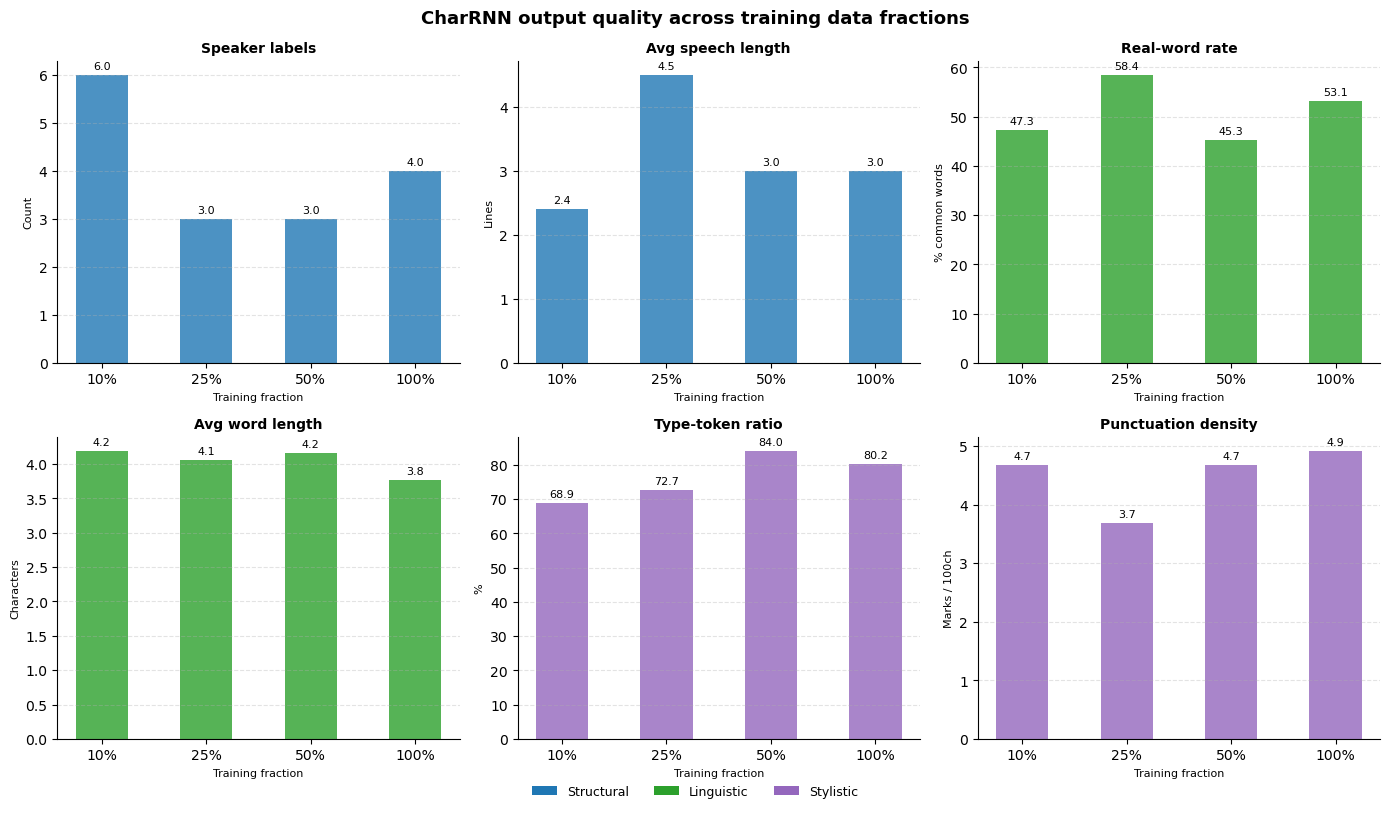

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("CharRNN output quality across training data fractions", fontsize=13, fontweight="bold")

plot_metrics = [
    ("speaker_labels", "Speaker labels",       "Count",          "Structural"),
    ("avg_speech_len", "Avg speech length",    "Lines",          "Structural"),
    ("real_word_rate", "Real-word rate",        "% common words", "Linguistic"),
    ("avg_word_len",   "Avg word length",       "Characters",     "Linguistic"),
    ("ttr",            "Type-token ratio",      "%",              "Stylistic"),
    ("punct_per_100",  "Punctuation density",   "Marks / 100ch",  "Stylistic"),
]

colors = {"Structural": "#1f77b4", "Linguistic": "#2ca02c", "Stylistic": "#9467bd"}
xlabels = [f"{int(f*100)}%" for f in samples.keys()]

for ax, (key, title, ylabel, category) in zip(axes.flat, plot_metrics):
    vals = [analysis[f][key] for f in FRACTIONS]
    ax.bar(xlabels, vals, color=colors[category], alpha=0.8, width=0.5)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=8)
    ax.set_xlabel("Training fraction", fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    for i, v in enumerate(vals):
        ax.text(i, v + max(vals)*0.02, f"{v:.1f}", ha="center", fontsize=8)

# category legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=cat) for cat, c in colors.items()]
fig.legend(handles=legend_elements, loc="lower center", ncol=3,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig("charRNN_analysis.png", dpi=150, bbox_inches="tight")
plt.show()